# Spot Detection: Demosaicing Method Comparison

**Date:** 2026-01-21

**Purpose:** Comprehensive comparison of demosaicing methods for spot detection in Bayer-patterned SMLM images

**Methods Tested:**
- **Variance-Aware Demosaicing:** Malvar, Bilinear, Menon2007
- **Standard Demosaicing:** Malvar, Bilinear, Menon2007 (no variance weighting)
- **Raw Bayer:** No demosaicing, direct photoelectron conversion

**Key Questions:**
1. Does variance-aware demosaicing improve spot detection vs standard demosaicing?
2. Which demosaicing algorithm performs best?
3. How does performance vary with photon count and molecular density?
4. Is demosaicing better than using raw Bayer images?

## 1. Setup & Imports

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import types
from tqdm.notebook import tqdm
import pandas as pd
from scipy.optimize import linear_sum_assignment

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

from Multicolour_Simulation_Functions import MultiC_Sim_Funcs
from sCMOSFunctions import sCMOS_Functions
from SpectralFunctions import Spectral_Funcs
from MaskFunctions import Mask_Functions
from IOFunctions import IO_Functions
from SpotDetectionFunctions import SpotDetection_Functions

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Imports complete")

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/notebooks/../logs/Constants_20260204_140846.log


✓ Imports complete


## 2. Load Camera Parameters and Setup

In [2]:
# Simulation parameters
image_size = 256  # pixels
pixel_size = 69.0  # nm
n_bootstrap = 1000  # bootstrap samples per condition

# Test conditions
photon_counts = np.logspace(np.log10(500), np.log10(20000), 8).astype(int)
molecular_densities = [50, 100, 150]  # molecules per frame

print(f"Image size: {image_size}×{image_size} pixels")
print(f"Bootstrap samples: {n_bootstrap}")
print(f"Photon counts to test: {photon_counts}")
print(f"Molecular densities: {molecular_densities}")

Image size: 256×256 pixels
Bootstrap samples: 1000
Photon counts to test: [  499   846  1434  2429  4115  6971 11807 20000]
Molecular densities: [50, 100, 150]


In [3]:
# Load real camera calibration from Ximea camera
IO = IO_Functions()
data_folder = "../Camera_Calibrations/Ximea_Camera/"

print(f"Loading camera calibration from {data_folder}...")
gain_full = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_full = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance_full = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise_full = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe_full = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

# Crop to 256x256 from center
h, w = gain_full.shape
center_y, center_x = h // 2, w // 2
half_size = image_size // 2

y_start = center_y - half_size
y_end = center_y + half_size
x_start = center_x - half_size
x_end = center_x + half_size

gain_map = gain_full[y_start:y_end, x_start:x_end]
offset_map = offset_full[y_start:y_end, x_start:x_end]
variance_map = variance_full[y_start:y_end, x_start:x_end]
readnoise_map = readnoise_full[y_start:y_end, x_start:x_end]
rqe_map = rqe_full[y_start:y_end, x_start:x_end]

# Setup masks and spectral functions
M_F = Mask_Functions()
S_F = Spectral_Funcs()

masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_parameters = {
    "gain": gain_map,
    "offset": offset_map,
    "variance": variance_map,
    "readnoise": readnoise_map,
    "rqe": rqe_map,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": [0, 1, 2],
    "masks": masks,
}

print(f"\n✓ Real camera parameters loaded")
print(f"  Gain range: [{gain_map.min():.3f}, {gain_map.max():.3f}] ADU/pe")
print(f"  Offset range: [{offset_map.min():.1f}, {offset_map.max():.1f}] ADU")
print(f"  Variance range: [{variance_map.min():.2f}, {variance_map.max():.2f}] ADU²")

Loading camera calibration from ../Camera_Calibrations/Ximea_Camera/...

✓ Real camera parameters loaded
  Gain range: [0.390, 0.433] ADU/pe
  Offset range: [30.3, 73.2] ADU
  Variance range: [0.75, 30.49] ADU²


In [4]:
# Dye and PSF parameters - ATTO 565
dye_name = "ATTO 565"

# Load ATTO 565 emission spectrum
atto565_spectrum = S_F.get_dye_or_filter_data(dye_name, wavelength, dye_or_filter=True)
if atto565_spectrum.ndim > 1:
    atto565_spectrum = np.squeeze(atto565_spectrum)
atto565_spectrum = atto565_spectrum / np.sum(atto565_spectrum)

# Calculate pixel efficiencies
average_emission_wavelength, dye_pixel_efficiency = S_F.get_pixel_fractions_rawspectra(
    wavelength=wavelength, 
    pixel_QYs=pixel_QYs, 
    spectra=atto565_spectrum
)

print(f"✓ Dye: {dye_name}")
print(f"  Emission wavelength: {average_emission_wavelength:.1f} nm")
print(f"  Pixel efficiencies (B, G, R): [{dye_pixel_efficiency[0]:.3f}, {dye_pixel_efficiency[1]:.3f}, {dye_pixel_efficiency[2]:.3f}]")

# Other parameters
background_photons = 10.0
NA = 1.49

# Setup smoothing function (PSF)
scmos = sCMOS_Functions()
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = scmos.gaussian_filter_stack
smoothing_function.data_arg = "image"

print(f"  Background: {background_photons} photons/pixel")
print(f"  NA: {NA}")

✓ Dye: ATTO 565
  Emission wavelength: 611.9 nm
  Pixel efficiencies (B, G, R): [0.024, 0.330, 0.494]
  Background: 10.0 photons/pixel
  NA: 1.49


## 3. Ground Truth Generation Function

In [5]:
def generate_test_simulation(n_photons_per_molecule, n_molecules=50):
    """
    Generate a single test simulation with ground truth.
    
    Args:
        n_photons_per_molecule: Number of photons per molecule
        n_molecules: Number of molecules to place in image
        
    Returns:
        bayer_adu: Bayer-patterned image in ADU (256, 256)
        true_positions_nm: True molecule positions in nm (n_molecules, 2)
        true_positions_px: True molecule positions in pixels (n_molecules, 2)
    """
    # Generate random molecule positions (keep away from edges)
    border = 20
    x_positions_nm = np.random.uniform(
        border * pixel_size, 
        (image_size - border) * pixel_size, 
        n_molecules
    )
    y_positions_nm = np.random.uniform(
        border * pixel_size, 
        (image_size - border) * pixel_size, 
        n_molecules
    )
    
    # Create x0y0 dictionary: shape (n_frames, 2, n_molecules)
    x0y0 = {'dye': np.zeros((1, 2, n_molecules))}
    x0y0['dye'][0, 0, :] = x_positions_nm
    x0y0['dye'][0, 1, :] = y_positions_nm
    
    # Single photon count (all molecules get same number)
    n_photons = {'dye': n_photons_per_molecule}
    
    # Generate simulation
    MSF = MultiC_Sim_Funcs()
    bayer_adu, _, _ = MSF.gen_camera_image_stack(
        camera_calibration=camera_parameters,
        wavelength=wavelength,
        average_emission_wavelengths=average_emission_wavelength,
        dye_pixel_efficiency=dye_pixel_efficiency,
        n_photons=n_photons,
        x0y0=x0y0,
        smoothing_function=smoothing_function,
        background_photons=background_photons,
        NA=NA,
        pixel_size=pixel_size,
        return_normal_image=False,
    )
    
    # Convert positions to pixels for matching
    true_positions_nm = np.column_stack([x_positions_nm, y_positions_nm])
    true_positions_px = true_positions_nm / pixel_size
    
    return np.squeeze(bayer_adu), true_positions_nm, true_positions_px

# Test the function
test_bayer, test_pos_nm, test_pos_px = generate_test_simulation(2000, n_molecules=50)
print(f"✓ Simulation function working")
print(f"  Bayer image shape: {test_bayer.shape}")
print(f"  True positions shape: {test_pos_px.shape}")
print(f"  Number of molecules: {len(test_pos_px)}")

✓ Simulation function working
  Bayer image shape: (256, 256)
  True positions shape: (50, 2)
  Number of molecules: 50


## 4. Image Preparation Methods

Test both variance-aware and non-variance-aware demosaicing methods.

In [6]:
def prepare_variance_aware_demosaic(bayer_adu, strategy='malvar'):
    """
    Prepare variance-aware demosaiced photoelectron image.
    
    Args:
        bayer_adu: Bayer-patterned image in ADU
        strategy: Demosaicing strategy ('malvar', 'menon2007', 'ddfapd', 'bilinear')
        
    Returns:
        pe_image: Grayscale photoelectron image (variance-aware demosaiced)
    """
    pe_image = scmos.variance_aware_demosaic(
        CFA=bayer_adu,
        variance_map=variance_map,
        offset_map=offset_map,
        gain=gain_map,
        grayscale=True,
        strategy=strategy
    )
    return pe_image


def prepare_standard_demosaic(bayer_adu, strategy='malvar'):
    """
    Prepare standard (non-variance-aware) demosaiced photoelectron image.
    
    Args:
        bayer_adu: Bayer-patterned image in ADU
        strategy: Demosaicing strategy ('malvar', 'menon2007', 'ddfapd', 'bilinear')
        
    Returns:
        pe_image: Grayscale photoelectron image (standard demosaiced)
    """
    # Convert to photoelectrons first
    bayer_pe = (bayer_adu - offset_map) / gain_map
    
    # Apply standard demosaicing (no variance weighting)
    rgb_pe, gray_pe = scmos.bayer_demosaic_stack(
        bayer_pe,
        grayscale=True,
        strategy=strategy
    )
    
    return gray_pe


def prepare_bayer_pe_image(bayer_adu):
    """
    Convert Bayer ADU to photoelectrons without demosaicing.
    
    Args:
        bayer_adu: Bayer-patterned image in ADU
        
    Returns:
        pe_bayer: Photoelectron image still in Bayer pattern
    """
    # Pixel-wise conversion: no interpolation
    pe_bayer = (bayer_adu - offset_map) / gain_map
    return pe_bayer


# Define methods to test
methods = {
    # Variance-aware demosaicing methods
    'var_malvar': lambda img: prepare_variance_aware_demosaic(img, 'malvar'),
    'var_bilinear': lambda img: prepare_variance_aware_demosaic(img, 'bilinear'),
    'var_menon2007': lambda img: prepare_variance_aware_demosaic(img, 'menon2007'),
    
    # No demosaicing (raw Bayer in photoelectrons)
    'bayer_pe': lambda img: prepare_bayer_pe_image(img),
}

print(f"✓ Defined {len(methods)} image preparation methods:")
print("\nVariance-Aware Demosaicing:")
for method_name in methods.keys():
    if method_name.startswith('var_'):
        print(f"  - {method_name}")
        
print("\nNo Demosaicing:")
for method_name in methods.keys():
    if method_name == 'bayer_pe':
        print(f"  - {method_name}")

✓ Defined 4 image preparation methods:

Variance-Aware Demosaicing:
  - var_malvar
  - var_bilinear
  - var_menon2007

No Demosaicing:
  - bayer_pe


## 5. Spot Detection Setup

In [7]:
# Initialize spot detector
detector = SpotDetection_Functions()

# Fixed detection parameters (same for all methods)
# NOTE: wavelength and pixel_size must be in MICRONS for detect_puncta_in_image
detection_params = {
    'pfa': 1e-3,  # Probability of false alarm
    'wavelength': average_emission_wavelength / 1000.0,  # Convert nm to microns
    'pixel_size': pixel_size / 1000.0,  # Convert nm to microns
    'NA': NA,
    'variance': variance_map,  # Pass variance map for better detection
}

print("✓ Spot detector initialized")
print(f"  Detection parameters:")
print(f"    pfa: {detection_params['pfa']}")
print(f"    wavelength: {detection_params['wavelength']:.4f} µm ({average_emission_wavelength:.1f} nm)")
print(f"    pixel_size: {detection_params['pixel_size']:.4f} µm ({pixel_size:.1f} nm)")
print(f"    NA: {detection_params['NA']}")

✓ Spot detector initialized
  Detection parameters:
    pfa: 0.001
    wavelength: 0.6119 µm (611.9 nm)
    pixel_size: 0.0690 µm (69.0 nm)
    NA: 1.49


## 6. Matching & Metrics Functions

In [8]:
def match_spots_to_ground_truth(detected_spots, true_positions_px, max_distance=3.0):
    """
    Match detected spots to ground truth using Hungarian algorithm.
    
    Args:
        detected_spots: (N_detected, 2) array of (x, y) positions in pixels
        true_positions_px: (N_true, 2) array of true (x, y) in pixels
        max_distance: Maximum distance (pixels) for valid match
        
    Returns:
        matches: List of (true_idx, detected_idx, distance) tuples
        unmatched_true: Indices of true spots not detected
        false_positives: Indices of detected spots not matched
    """
    if len(detected_spots) == 0:
        # No detections - all true spots are unmatched
        return [], list(range(len(true_positions_px))), []
    
    if len(true_positions_px) == 0:
        # No true spots - all detections are false positives
        return [], [], list(range(len(detected_spots)))
    
    # Compute distance matrix
    distances = np.sqrt(
        (detected_spots[:, 0][:, None] - true_positions_px[:, 0])**2 +
        (detected_spots[:, 1][:, None] - true_positions_px[:, 1])**2
    )
    
    # Hungarian matching
    detected_idx, true_idx = linear_sum_assignment(distances)
    
    # Filter by max_distance
    valid = distances[detected_idx, true_idx] < max_distance
    matches = [
        (true_idx[i], detected_idx[i], distances[detected_idx[i], true_idx[i]])
        for i in range(len(true_idx)) if valid[i]
    ]
    
    # Find unmatched
    matched_true = set(t for t, d, dist in matches)
    matched_detected = set(d for t, d, dist in matches)
    
    unmatched_true = [i for i in range(len(true_positions_px)) if i not in matched_true]
    false_positives = [i for i in range(len(detected_spots)) if i not in matched_detected]
    
    return matches, unmatched_true, false_positives


def calculate_detection_metrics(matches, unmatched_true, false_positives):
    """
    Calculate detection and localization metrics.
    """
    # Localization errors (only for matched spots)
    localization_errors = np.array([dist for t, d, dist in matches])
    
    # Detection metrics
    n_true = len(matches) + len(unmatched_true)
    n_detected = len(matches) + len(false_positives)
    
    recall = len(matches) / n_true if n_true > 0 else 0
    precision = len(matches) / n_detected if n_detected > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'recall': recall,
        'precision': precision,
        'f1_score': f1_score,
        'n_matched': len(matches),
        'n_missed': len(unmatched_true),
        'n_false_positives': len(false_positives),
        'n_true': n_true,
        'n_detected': n_detected,
        'localization_rmse': np.sqrt(np.mean(localization_errors**2)) if len(localization_errors) > 0 else np.nan,
        'localization_mean': np.mean(localization_errors) if len(localization_errors) > 0 else np.nan,
        'localization_median': np.median(localization_errors) if len(localization_errors) > 0 else np.nan,
    }

print("✓ Matching and metrics functions defined")

✓ Matching and metrics functions defined


## 7. Bootstrap Validation Loop

Test all methods across photon counts and molecular densities.

In [9]:
# Storage for all results
all_results = []

# Total iterations
total_iterations = len(photon_counts) * len(molecular_densities) * n_bootstrap * len(methods)

print(f"Starting bootstrap validation...")
print(f"Total iterations: {total_iterations}")
print(f"  Photon counts: {len(photon_counts)}")
print(f"  Molecular densities: {len(molecular_densities)}")
print(f"  Bootstrap samples: {n_bootstrap}")
print(f"  Methods: {len(methods)}")
print()

with tqdm(total=total_iterations, desc="Overall progress") as pbar:
    for n_photons in photon_counts:
        for n_molecules in molecular_densities:
            for i_boot in range(n_bootstrap):
                # Generate simulation
                bayer_img, true_pos_nm, true_pos_px = generate_test_simulation(
                    n_photons, n_molecules
                )
                
                # Test all image preparation methods
                for method_name, method_func in methods.items():
                    # Prepare image
                    pe_image = method_func(bayer_img)
                    
                    # Detect spots using SpotDetectionFunctions
                    try:
                        detected_spots = detector.detect_puncta_in_image(
                            pe_image,
                            **detection_params
                        )
                        
                        # Extract positions
                        # detect_puncta_in_image returns (N, 2) array of [x, y] positions
                        if len(detected_spots) > 0:
                            detected_positions = detected_spots
                        else:
                            detected_positions = np.array([]).reshape(0, 2)
                        
                    except Exception as e:
                        # If detection fails, record as no detections
                        print(f"\\nDetection failed for {method_name} (photons={n_photons}, molecules={n_molecules}): {e}")
                        detected_positions = np.array([]).reshape(0, 2)
                    
                    # Match to ground truth
                    matches, unmatched, fps = match_spots_to_ground_truth(
                        detected_positions, true_pos_px
                    )
                    
                    # Calculate metrics
                    metrics = calculate_detection_metrics(matches, unmatched, fps)
                    
                    # Store results
                    result = {
                        'method': method_name,
                        'n_photons': n_photons,
                        'n_molecules': n_molecules,
                        'bootstrap_idx': i_boot,
                        **metrics
                    }
                    all_results.append(result)
                    
                    pbar.update(1)

# Convert to DataFrame
df_results = pd.DataFrame(all_results)

print(f"\\n✓ Bootstrap validation complete!")
print(f"  Total results: {len(df_results)}")
print(f"\\nDataFrame preview:")
print(df_results.head())

Starting bootstrap validation...
Total iterations: 96000
  Photon counts: 8
  Molecular densities: 3
  Bootstrap samples: 1000
  Methods: 4



Overall progress:   0%|          | 0/96000 [00:00<?, ?it/s]

\n✓ Bootstrap validation complete!
  Total results: 96000
\nDataFrame preview:
          method  n_photons  n_molecules  bootstrap_idx  recall  precision  \
0     var_malvar        499           50              0    0.30   1.000000   
1   var_bilinear        499           50              0    0.56   0.903226   
2  var_menon2007        499           50              0    0.24   1.000000   
3       bayer_pe        499           50              0    0.22   0.916667   
4     var_malvar        499           50              1    0.30   1.000000   

   f1_score  n_matched  n_missed  n_false_positives  n_true  n_detected  \
0  0.461538         15        35                  0      50          15   
1  0.691358         28        22                  3      50          31   
2  0.387097         12        38                  0      50          12   
3  0.354839         11        39                  1      50          12   
4  0.461538         15        35                  0      50          15   

 

## 8. Aggregate Statistics

In [10]:
# Group by method, photon count, and density
metric_cols = ['recall', 'precision', 'f1_score', 'localization_rmse', 'localization_mean']

df_stats = df_results.groupby(['method', 'n_photons', 'n_molecules'])[metric_cols].agg(
    ['mean', 'std', 'median']
)

# Flatten column names
df_stats.columns = ['_'.join(col).strip() for col in df_stats.columns.values]
df_stats = df_stats.reset_index()

print("✓ Statistics aggregated")
print(f"\nSummary statistics (first few rows):")
print(df_stats.head(10))

✓ Statistics aggregated

Summary statistics (first few rows):
     method  n_photons  n_molecules  recall_mean  recall_std  recall_median  \
0  bayer_pe        499           50     0.187040    0.054360       0.180000   
1  bayer_pe        499          100     0.152280    0.034187       0.150000   
2  bayer_pe        499          150     0.128627    0.026217       0.126667   
3  bayer_pe        846           50     0.418340    0.070786       0.420000   
4  bayer_pe        846          100     0.295520    0.044721       0.290000   
5  bayer_pe        846          150     0.220693    0.034328       0.220000   
6  bayer_pe       1434           50     0.594460    0.077644       0.600000   
7  bayer_pe       1434          100     0.398820    0.048639       0.400000   
8  bayer_pe       1434          150     0.284353    0.035984       0.286667   
9  bayer_pe       2429           50     0.640700    0.080294       0.640000   

   precision_mean  precision_std  precision_median  f1_score_mean  \

## 9. Visualization: Recall vs Photon Count

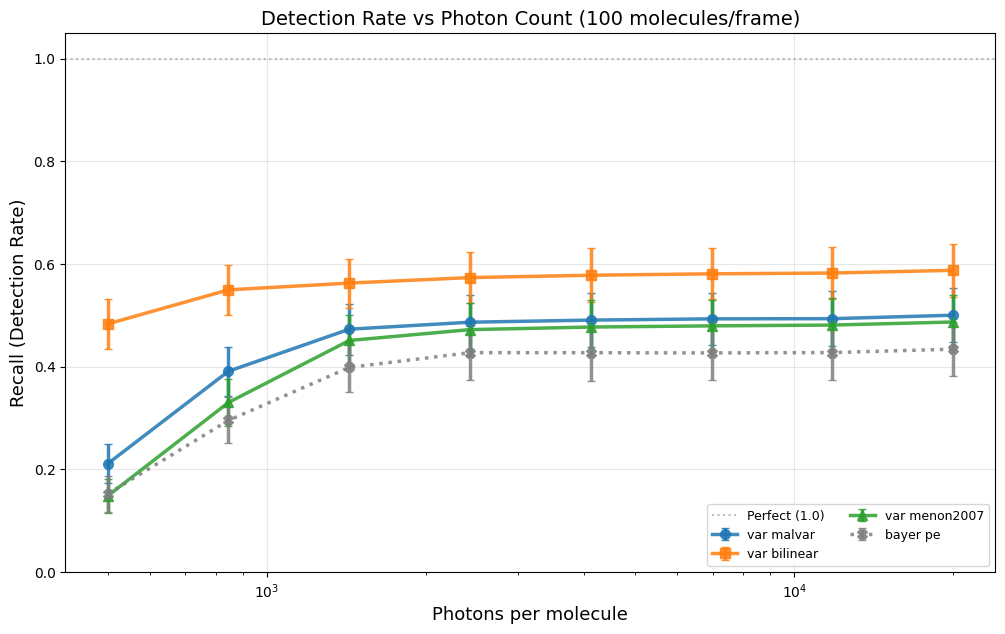

✓ Recall vs photon count plotted


In [13]:
# Plot recall vs photon count for medium density
medium_density = molecular_densities[len(molecular_densities)//2]

fig, ax = plt.subplots(figsize=(12, 7))

# Define colors and markers for all methods
colors = {
    'var_malvar': '#1f77b4', 'var_bilinear': '#ff7f0e', 'var_menon2007': '#2ca02c',
    'bayer_pe': '#7f7f7f'
}
markers = {
    'var_malvar': 'o', 'var_bilinear': 's', 'var_menon2007': '^',
    'bayer_pe': 'X'
}
linestyles = {
    'var_malvar': '-', 'var_bilinear': '-', 'var_menon2007': '-',
    'bayer_pe': ':'
}

for method in methods.keys():
    data = df_stats[(df_stats['method'] == method) & 
                    (df_stats['n_molecules'] == medium_density)]
    
    ax.errorbar(
        data['n_photons'],
        data['recall_mean'],
        yerr=data['recall_std'],
        label=method.replace('_', ' '),
        color=colors[method],
        marker=markers[method],
        linestyle=linestyles[method],
        markersize=7,
        capsize=3,
        linewidth=2.5,
        alpha=0.85
    )

ax.set_xlabel('Photons per molecule', fontsize=13)
ax.set_ylabel('Recall (Detection Rate)', fontsize=13)
ax.set_xscale('log')
ax.set_ylim([0, 1.05])
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='Perfect (1.0)')
ax.legend(fontsize=9, ncol=2, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_title(f'Detection Rate vs Photon Count ({medium_density} molecules/frame)', fontsize=14)

#plt.tight_layout()
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Spot_detection/'
plt.savefig(os.path.join(folder, 'spot_detection_recall_vs_photons.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Recall vs photon count plotted")

## 10. Visualization: F1 Score Comparison

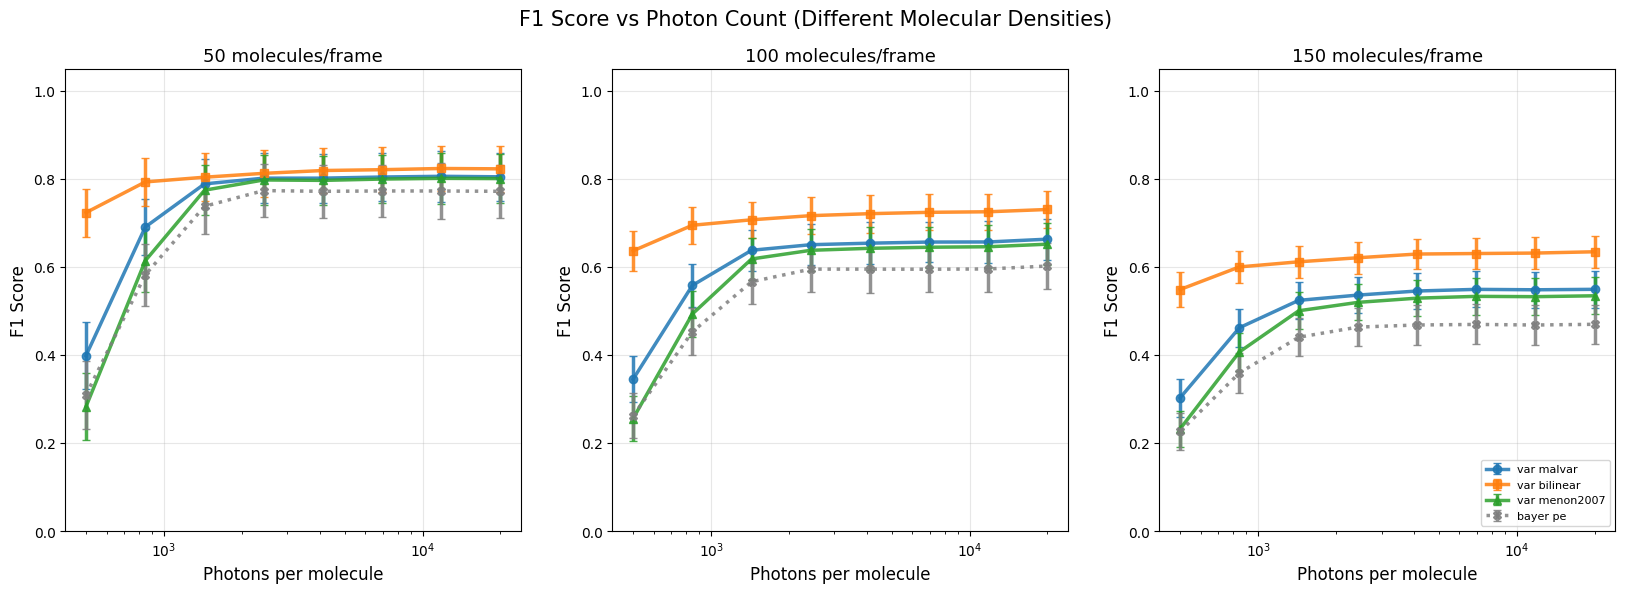

✓ F1 score comparison plotted


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Use same colors/markers as previous plot
for idx, n_mol in enumerate(molecular_densities):
    ax = axes[idx]
    
    for method in methods.keys():
        data = df_stats[(df_stats['method'] == method) & 
                        (df_stats['n_molecules'] == n_mol)]
        
        ax.errorbar(
            data['n_photons'],
            data['f1_score_mean'],
            yerr=data['f1_score_std'],
            label=method.replace('_', ' '),
            color=colors[method],
            marker=markers[method],
            linestyle=linestyles[method],
            markersize=6,
            capsize=3,
            linewidth=2.5,
            alpha=0.85
        )
    
    ax.set_xlabel('Photons per molecule', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])
    ax.set_title(f'{n_mol} molecules/frame', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    if idx == 2:
        ax.legend(fontsize=8, loc='lower right', ncol=1)

plt.suptitle('F1 Score vs Photon Count (Different Molecular Densities)', fontsize=15)
#plt.tight_layout()
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/Spot_detection/'
plt.savefig(os.path.join(folder, 'spot_detection_f1_vs_photons_density.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ F1 score comparison plotted")

## 11. Variance-Aware vs Standard Comparison

Direct comparison of variance-aware vs standard demosaicing for each algorithm.

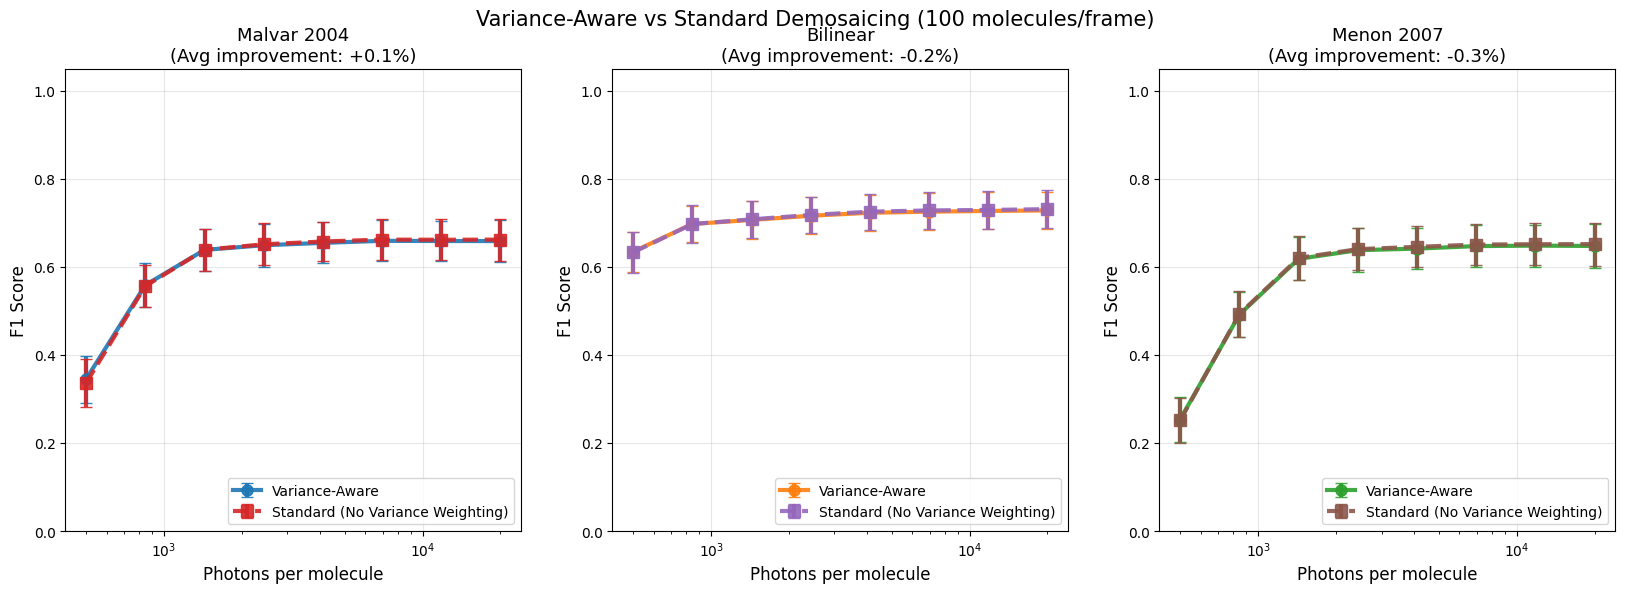

✓ Variance-aware vs standard comparison plotted


In [32]:
# Compare variance-aware vs standard for each demosaicing algorithm
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

algorithms = ['malvar', 'bilinear', 'menon2007']
titles = ['Malvar 2004', 'Bilinear', 'Menon 2007']

for idx, (alg, title) in enumerate(zip(algorithms, titles)):
    ax = axes[idx]
    
    # Variance-aware version
    var_method = f'var_{alg}'
    data_var = df_stats[(df_stats['method'] == var_method) & 
                        (df_stats['n_molecules'] == medium_density)]
    
    ax.errorbar(
        data_var['n_photons'],
        data_var['f1_score_mean'],
        yerr=data_var['f1_score_std'],
        label='Variance-Aware',
        color=colors[var_method],
        marker='o',
        markersize=8,
        capsize=4,
        linewidth=3,
        alpha=0.9
    )
    
    # Standard version
    std_method = f'std_{alg}'
    data_std = df_stats[(df_stats['method'] == std_method) & 
                        (df_stats['n_molecules'] == medium_density)]
    
    ax.errorbar(
        data_std['n_photons'],
        data_std['f1_score_mean'],
        yerr=data_std['f1_score_std'],
        label='Standard (No Variance Weighting)',
        color=colors[std_method],
        marker='s',
        markersize=8,
        capsize=4,
        linewidth=3,
        linestyle='--',
        alpha=0.9
    )
    
    # Compute improvement
    improvement = ((data_var['f1_score_mean'].values - data_std['f1_score_mean'].values) / 
                   data_std['f1_score_mean'].values * 100)
    avg_improvement = np.mean(improvement)
    
    ax.set_xlabel('Photons per molecule', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])
    ax.set_title(f'{title}\n(Avg improvement: {avg_improvement:+.1f}%)', fontsize=13)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Variance-Aware vs Standard Demosaicing ({medium_density} molecules/frame)', fontsize=15)
#plt.tight_layout()
#plt.savefig('spot_detection_variance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Variance-aware vs standard comparison plotted")

## 12. Localization Error

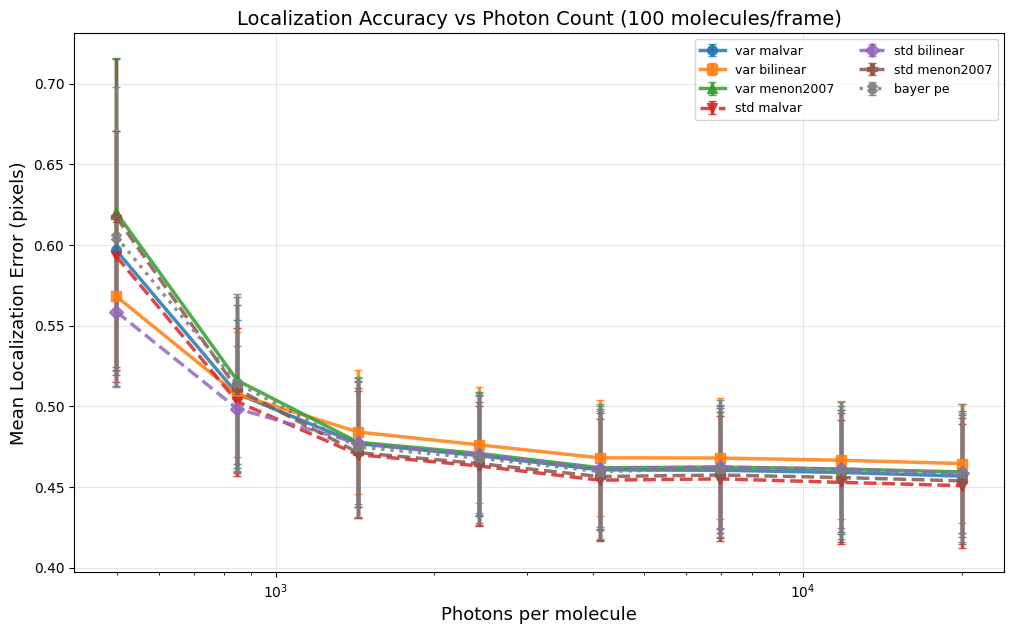

✓ Localization error plotted


In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

for method in methods.keys():
    data = df_stats[(df_stats['method'] == method) & 
                    (df_stats['n_molecules'] == medium_density)]
    
    ax.errorbar(
        data['n_photons'],
        data['localization_mean_mean'],
        yerr=data['localization_mean_std'],
        label=method.replace('_', ' '),
        color=colors[method],
        marker=markers[method],
        linestyle=linestyles[method],
        markersize=7,
        capsize=3,
        linewidth=2.5,
        alpha=0.85
    )

ax.set_xlabel('Photons per molecule', fontsize=13)
ax.set_ylabel('Mean Localization Error (pixels)', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_title(f'Localization Accuracy vs Photon Count ({medium_density} molecules/frame)', fontsize=14)

#plt.tight_layout()
#plt.savefig('spot_detection_localization_vs_photons.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Localization error plotted")

## 13. Summary Table

# Create overall summary (averaged across all conditions)
summary = df_results.groupby('method')[metric_cols].agg(['mean', 'std']).round(4)

# Flatten columns
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# Sort by F1 score
summary = summary.sort_values('f1_score_mean', ascending=False)
summary['rank'] = range(1, len(summary) + 1)

print("="*120)
print("SUMMARY: Average Performance Across All Conditions")
print("="*120)
print(summary.to_string(index=False))
print("="*120)

# Save results
summary.to_csv('spot_detection_summary.csv', index=False)
df_stats.to_csv('spot_detection_detailed.csv', index=False)

print("\n✓ Summary statistics saved to CSV")

# Print variance-aware vs standard comparison
print("\n" + "="*120)
print("VARIANCE-AWARE vs STANDARD COMPARISON")
print("="*120)
for alg in ['malvar', 'bilinear', 'menon2007']:
    var_method = f'var_{alg}'
    std_method = f'std_{alg}'
    
    var_f1 = summary[summary['method'] == var_method]['f1_score_mean'].values[0]
    std_f1 = summary[summary['method'] == std_method]['f1_score_mean'].values[0]
    
    improvement = (var_f1 - std_f1) / std_f1 * 100
    
    print(f"{alg.upper():12s}: var={var_f1:.4f}  std={std_f1:.4f}  improvement={improvement:+6.2f}%")
print("="*120)